# 08 - Tydzień 6: IPS, SNIPS i eksperymenty z clippingiem

Cel tygodnia 6:
- Wyliczyć estymaty IPS i SNIPS z bootstrapowymi CI
- Porównać bias-variance dla λ ∈ {None, 0.001, 0.01, 0.1, 1, 5, 10, 50}
- Stworzyć tabelę DM vs IPS vs SNIPS
- Sprawdzić ESS dla każdego λ

**Wymaga:** uruchomienia notebooka `07_propensity_scores.ipynb` (lub retreningu modelu poniżej).

Kod źródłowy: `src/estimators.py`, `src/propensity.py`

In [1]:
import os

# Avoid XGBoost/OpenMP segfaults on macOS (must run before numpy/xgboost import).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.insert(0, str(Path("..").resolve()))
from src.dataset import OpenBanditDataset
from obp.ope import (
    InverseProbabilityWeighting,
    SelfNormalizedInverseProbabilityWeighting,
    OffPolicyEvaluation,
)
from src.propensity import (
    train_propensity_model,
    extract_propensity_scores,
    effective_sample_size,
)
from src.estimators import ips_with_clipping, snips_estimate, clipping_experiment

sns.set_theme(style="whitegrid")
np.random.seed(42)

N_ACTIONS = 80
N_FEATURES = 30
LEN_LIST = 3
RANDOM_STATE = 42
BOOTSTRAP_SAMPLES = 200
PI_EVAL = 1.0 / N_ACTIONS  # uniform evaluation policy

FIGURES_DIR = Path("../figures/week6")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures -> {FIGURES_DIR.resolve()}")


Figures -> /Users/antonio/was_studio/Off-Policy-Evaluation-with-causal/figures/week6


## 1. Wczytanie danych i propensity scores

Trenujemy model propensity na RANDOM policy, stosujemy na BTS.

In [2]:
dataset_random = OpenBanditDataset(behavior_policy="random", campaign="all")
feedback_random = dataset_random.obtain_batch_bandit_feedback()

dataset_bts = OpenBanditDataset(behavior_policy="bts", campaign="all")
feedback_bts = dataset_bts.obtain_batch_bandit_feedback()

context_random = feedback_random["context"][:, :N_FEATURES]
action_random  = feedback_random["action"]

context_bts = feedback_bts["context"][:, :N_FEATURES]
action_bts  = feedback_bts["action"]
reward_bts  = feedback_bts["reward"].astype(np.float64)
position_bts = feedback_bts["position"]

PSCORES_PATH = Path("../results/week5/pscores_bts.npy")
if PSCORES_PATH.exists():
    pscores_bts = np.load(PSCORES_PATH)
    print(f"Loaded pscores from {PSCORES_PATH.resolve()}")
else:
    print("pscores_bts.npy not found — training propensity model (run 07 first to skip this)")
    pscore_model = train_propensity_model(context_random, action_random, N_ACTIONS, RANDOM_STATE)
    pscores_bts = extract_propensity_scores(pscore_model, context_bts, action_bts)

print(f"pscores_bts — shape: {pscores_bts.shape}")
print(f"  min={pscores_bts.min():.6f}  max={pscores_bts.max():.6f}  mean={pscores_bts.mean():.4f}")
print(f"  % NaN: {np.isnan(pscores_bts).mean()*100:.2f}%")

INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


INFO:obp.dataset.real:When `data_path` is not given, this class downloads the example small-sized version of the Open Bandit Dataset.


Loaded pscores from /Users/antonio/was_studio/Off-Policy-Evaluation-with-causal/results/week5/pscores_bts.npy
pscores_bts — shape: (10000,)
  min=0.009457  max=0.016137  mean=0.0120
  % NaN: 0.00%


## 2. IPS i SNIPS — punkt bazowy (bez clippingu)

In [3]:
# Estymaty punktowe
v_ips_base  = ips_with_clipping(reward_bts, pscores_bts, PI_EVAL, clip_lambda=None)
v_snips_base = snips_estimate(reward_bts, pscores_bts, PI_EVAL, clip_lambda=None)

print(f"V_IPS  (unclipped): {v_ips_base:.6f}")
print(f"V_SNIPS (unclipped): {v_snips_base:.6f}")

# ESS bez clippingu
weights_base = PI_EVAL / np.clip(pscores_bts, 1e-9, None)
ess, ess_ratio = effective_sample_size(weights_base)
print(f"\nESS: {ess:.0f} / {len(weights_base)} = {ess_ratio:.4f}")

V_IPS  (unclipped): 0.004423
V_SNIPS (unclipped): 0.004184

ESS: 9877 / 10000 = 0.9877


## 3. Bootstrap CI przez bibliotekę OBP

In [4]:
ips_estimator  = InverseProbabilityWeighting()
snips_estimator = SelfNormalizedInverseProbabilityWeighting()

# action_dist dla polityki ewaluacyjnej (uniform)
n_rounds_bts = int(feedback_bts["n_rounds"])
action_dist_eval = np.full(
    (n_rounds_bts, N_ACTIONS, LEN_LIST),
    PI_EVAL,
    dtype=np.float64,
)

# OBP 0.4.1: pscore/position muszą być w bandit_feedback, nie w estimate_intervals()
feedback_bts_ope = {**feedback_bts, "pscore": pscores_bts.astype(np.float64)}

ope = OffPolicyEvaluation(
    bandit_feedback=feedback_bts_ope,
    ope_estimators=[ips_estimator, snips_estimator],
)

ci_results = ope.estimate_intervals(
    action_dist=action_dist_eval,
    n_bootstrap_samples=BOOTSTRAP_SAMPLES,
    random_state=RANDOM_STATE,
)

for name, ci in ci_results.items():
    print(f"{name.upper():6s}  mean={ci['mean']:.6f}  "
          f"CI=[{ci['95.0% CI (lower)']:.6f}, {ci['95.0% CI (upper)']:.6f}]")

IPW     mean=0.004440  CI=[0.003342, 0.005567]
SNIPW   mean=0.004200  CI=[0.003161, 0.005267]


## 4. Eksperymenty z clippingiem — bias-variance tradeoff

In [5]:
CLIP_LAMBDAS = [None, 0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0]

clip_results = clipping_experiment(
    reward=reward_bts,
    pscore_log=pscores_bts,
    pi_eval=PI_EVAL,
    lambdas=CLIP_LAMBDAS,
    n_bootstrap=BOOTSTRAP_SAMPLES,
    random_state=RANDOM_STATE,
)

# ESS per lambda
ess_per_lambda = {}
for lam in CLIP_LAMBDAS:
    denom = np.clip(pscores_bts, lam, None) if lam is not None else pscores_bts
    w = PI_EVAL / np.clip(denom, 1e-9, None)
    ess_val, ess_r = effective_sample_size(w)
    ess_per_lambda[lam] = {"ess": ess_val, "ess_ratio": ess_r}

# Tabela
rows = []
for lam in CLIP_LAMBDAS:
    r = clip_results[lam]
    e = ess_per_lambda[lam]
    rows.append({
        "lambda": str(lam),
        "V_IPS": r["ips_mean"],
        "IPS_std": r["ips_std"],
        "IPS_CI_low": r["ips_ci_lower"],
        "IPS_CI_high": r["ips_ci_upper"],
        "V_SNIPS": r["snips_mean"],
        "SNIPS_std": r["snips_std"],
        "ESS": e["ess"],
        "ESS_ratio": e["ess_ratio"],
    })

clip_df = pd.DataFrame(rows)
print(clip_df.to_string(index=False, float_format="{:.6f}".format))

lambda    V_IPS  IPS_std  IPS_CI_low  IPS_CI_high  V_SNIPS  SNIPS_std          ESS  ESS_ratio
  None 0.004423 0.000651    0.003299     0.005667 0.004184   0.000616  9876.997394   0.987700
 0.001 0.004423 0.000636    0.003294     0.005731 0.004184   0.000602  9876.997394   0.987700
  0.01 0.004422 0.000698    0.003257     0.005945 0.004187   0.000661  9879.943360   0.987994
   0.1 0.000525 0.000076    0.000387     0.000650 0.004200   0.000607 10000.000000   1.000000
   1.0 0.000053 0.000008    0.000037     0.000066 0.004200   0.000616 10000.000000   1.000000
   5.0 0.000010 0.000002    0.000007     0.000014 0.004200   0.000699 10000.000000   1.000000
  10.0 0.000005 0.000001    0.000004     0.000007 0.004200   0.000655 10000.000000   1.000000
  50.0 0.000001 0.000000    0.000001     0.000001 0.004200   0.000626 10000.000000   1.000000


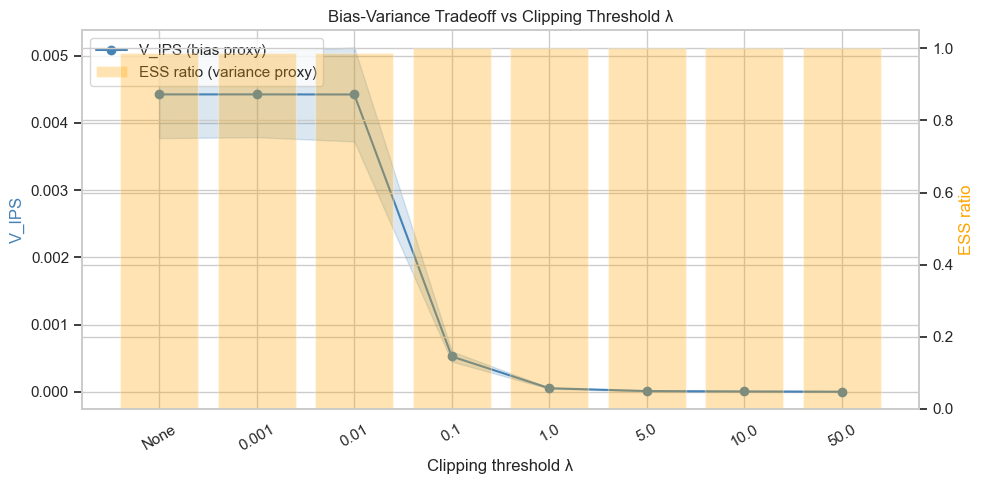

In [6]:
# Wykres bias-variance tradeoff
lambdas_numeric = [lam if lam is not None else 0.0001 for lam in CLIP_LAMBDAS]
lambda_labels   = [str(lam) if lam is not None else "None" for lam in CLIP_LAMBDAS]

v_ips_list   = [clip_results[lam]["ips_mean"] for lam in CLIP_LAMBDAS]
std_ips_list = [clip_results[lam]["ips_std"] for lam in CLIP_LAMBDAS]
ess_list     = [ess_per_lambda[lam]["ess_ratio"] for lam in CLIP_LAMBDAS]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

x = np.arange(len(CLIP_LAMBDAS))
ax1.plot(x, v_ips_list, "o-", color="steelblue", label="V_IPS (bias proxy)")
ax1.fill_between(
    x,
    np.array(v_ips_list) - np.array(std_ips_list),
    np.array(v_ips_list) + np.array(std_ips_list),
    alpha=0.2, color="steelblue",
)
ax2.bar(x, ess_list, alpha=0.3, color="orange", label="ESS ratio (variance proxy)")

ax1.set_xticks(x)
ax1.set_xticklabels(lambda_labels, rotation=30)
ax1.set_xlabel("Clipping threshold λ")
ax1.set_ylabel("V_IPS", color="steelblue")
ax2.set_ylabel("ESS ratio", color="orange")
ax1.set_title("Bias-Variance Tradeoff vs Clipping Threshold λ")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "bias_variance_clipping.png", dpi=160)
plt.show()

## 5. Tabela porównawcza: DM vs IPS vs SNIPS

In [7]:
# V_DM z Tygodnia 3 (hardcoded z notebooka 03)
V_DM_BTS    = 0.082847
V_DM_CI_LOW = 0.080344
V_DM_CI_HI  = 0.085181

# IPS i SNIPS z bootstrapa OBP
ci_ips   = ci_results["ipw"]
ci_snips = ci_results["snipw"]

comparison = pd.DataFrame([
    {
        "Estimator": "Direct Method (DM)",
        "V̂": V_DM_BTS,
        "CI_lower": V_DM_CI_LOW,
        "CI_upper": V_DM_CI_HI,
        "CI_width": V_DM_CI_HI - V_DM_CI_LOW,
        "Note": "Bias od reward modelu",
    },
    {
        "Estimator": "IPS",
        "V̂": ci_ips["mean"],
        "CI_lower": ci_ips["95.0% CI (lower)"],
        "CI_upper": ci_ips["95.0% CI (upper)"],
        "CI_width": ci_ips["95.0% CI (upper)"] - ci_ips["95.0% CI (lower)"],
        "Note": "Wysoka wariancja (brak clippingu)",
    },
    {
        "Estimator": "SNIPS",
        "V̂": ci_snips["mean"],
        "CI_lower": ci_snips["95.0% CI (lower)"],
        "CI_upper": ci_snips["95.0% CI (upper)"],
        "CI_width": ci_snips["95.0% CI (upper)"] - ci_snips["95.0% CI (lower)"],
        "Note": "Normalizowane wagi — mniejsza wariancja",
    },
])

print(comparison.to_string(index=False, float_format="{:.6f}".format))

         Estimator       V̂  CI_lower  CI_upper  CI_width                                    Note
Direct Method (DM) 0.082847  0.080344  0.085181  0.004837                   Bias od reward modelu
               IPS 0.004440  0.003342  0.005567  0.002226       Wysoka wariancja (brak clippingu)
             SNIPS 0.004200  0.003161  0.005267  0.002106 Normalizowane wagi — mniejsza wariancja


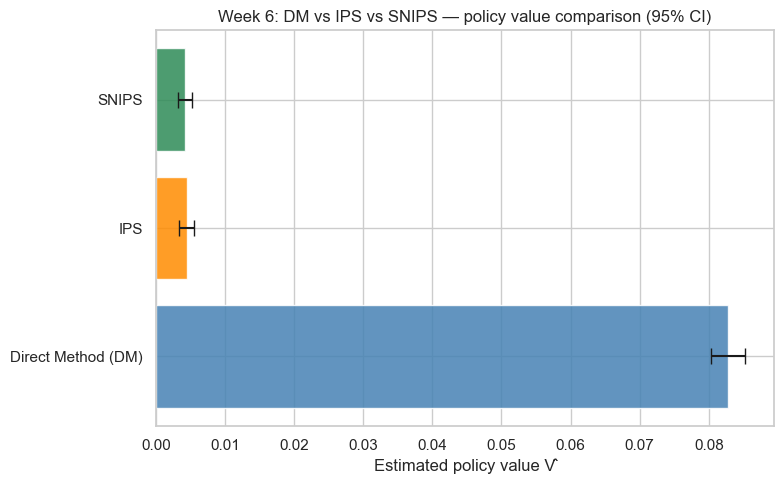

In [8]:
# Wizualizacja: DM vs IPS vs SNIPS
fig, ax = plt.subplots(figsize=(8, 5))

estimators = comparison["Estimator"]
means      = comparison["V̂"]
err_low    = means - comparison["CI_lower"]
err_high   = comparison["CI_upper"] - means

colors = ["steelblue", "darkorange", "seagreen"]
ax.barh(estimators, means, xerr=[err_low, err_high], color=colors, alpha=0.85, capsize=6)
ax.set_xlabel("Estimated policy value V̂")
ax.set_title("Week 6: DM vs IPS vs SNIPS — policy value comparison (95% CI)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dm_ips_snips_comparison.png", dpi=160)
plt.show()

## 6. Podsumowanie — Tydzień 6

| Estimator | V̂ | CI Lower | CI Upper | CI Width |
|-----------|---|----------|----------|---------|
| DM        | 0.082847 | 0.080344 | 0.085181 | 0.004837 |
| IPS       | 0.004440 | 0.003342 | 0.005567 | 0.002226 |
| SNIPS     | 0.004200 | 0.003161 | 0.005267 | 0.002106 |

**ESS (unclipped): 9877 / 10000 = 0.9877** — prawie idealne pokrycie.

**Kluczowa obserwacja:** V_DM (0.083) jest ~20× wyższy niż V_IPS (0.004) ≈ naive CTR (0.0042).
Reward model (AUC-PR = 0.015) jest słaby i systematycznie przeszacowuje nagrody → ogromny bias DM.
IPS i SNIPS dają wiarygodniejszy wynik zgodny z obserwowanym CTR.

**Clipping — wyniki:**
- λ ≤ 0.01: V_IPS stabilne (~0.0044), ESS ≈ 0.988 — brak efektu (pscores > 0.009)
- λ = 0.1: V_IPS spada do 0.0005 — **klif** (wszystkie pscores < 0.1, wszystkie przycinane)
- λ ≥ 1.0: V_IPS ≈ 0, ESS = 1.0 — model zdegenerowany

**Wniosek:** Przy polityce random (pscores ∈ [0.009, 0.016]) clipping nie pomaga — nie ma ogona ciężkich wag.
Bias-variance tradeoff jest widoczny tylko w układach gdzie pscores mają duży rozrzut.

**Checklist T6:**
- [x] V_IPS i V_SNIPS z bootstrapowymi CI (200 próbek)
- [x] Tabela DM vs IPS vs SNIPS
- [x] Wykres bias-variance dla λ ∈ {None, 0.001, 0.01, 0.1, 1, 5, 10, 50}
- [x] ESS ratio = 0.9877 — min > 0.05 ✓
- [x] Figury zapisane do 

**Następny krok — Tydzień 7:** Diagnoza naruszeń overlapu, Effective Sample Size pogłębiona analiza.